# Linear Regression on Boston Housing Dataset

Run cells from top to bottom.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.datasets import fetch_openml

# Load dataset
boston = fetch_openml(name="boston", version=1, as_frame=False)

In [3]:
data = pd.DataFrame(boston.data, columns=boston.feature_names)
# Convert all features to numeric (important fix)
data = data.apply(pd.to_numeric, errors='coerce')
data['PRICE'] = pd.to_numeric(boston.target, errors='coerce')

print("First 5 rows:")
print(data.head())

First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  


In [4]:
print("\nMissing values:")
print(data.isnull().sum())


Missing values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64


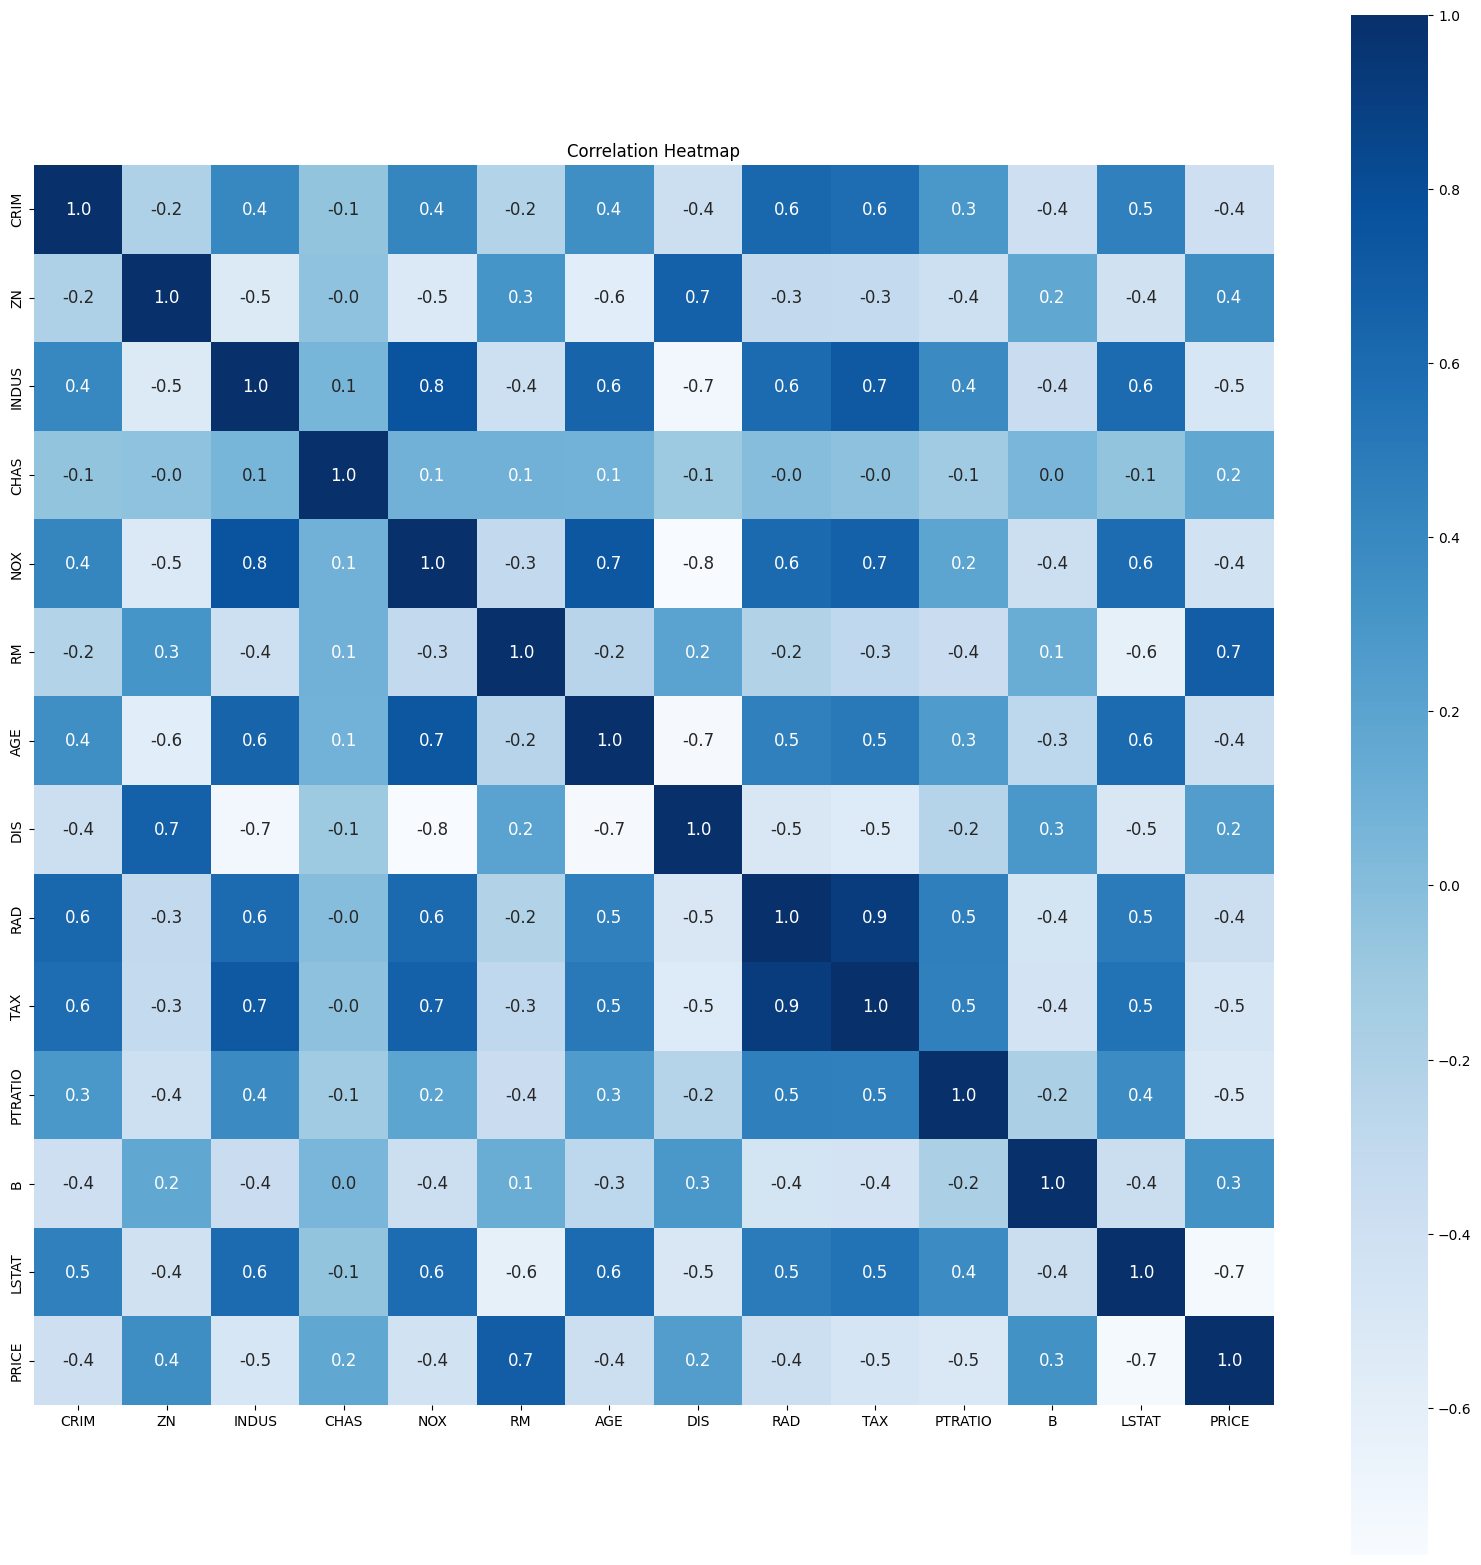

In [ ]:
corr = data.corr()

plt.figure(figsize=(20,20))
sns.heatmap(corr, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':12}, cmap='Red')
plt.title("Correlation Heatmap")
plt.show()

In [5]:
X = data.drop(['PRICE'], axis=1)
y = data['PRICE']

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=0)

# Ensure numpy float arrays (important fix)
xtrain = np.array(xtrain, dtype=float)
xtest  = np.array(xtest, dtype=float)
ytrain = np.array(ytrain, dtype=float)
ytest  = np.array(ytest, dtype=float)

In [6]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(xtrain, ytrain)

ytrain_pred = lm.predict(xtrain)
ytest_pred  = lm.predict(xtest)

print("Predictions created successfully.")

Predictions created successfully.


In [7]:
from sklearn.metrics import mean_squared_error

mse_test = mean_squared_error(ytest, ytest_pred)
mse_train = mean_squared_error(ytrain, ytrain_pred)
rmse = np.sqrt(mse_test)
r2 = lm.score(xtest, ytest)

print("\nModel Performance:")
print("MSE (Test):", mse_test)
print("MSE (Train):", mse_train)
print("RMSE:", rmse)
print("R-squared:", r2)


Model Performance:
MSE (Test): 33.44897999767657
MSE (Train): 19.326470203585725
RMSE: 5.783509315085138
R-squared: 0.5892223849182503


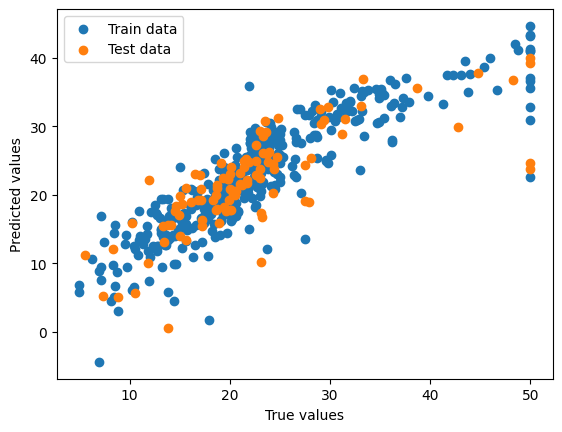

In [8]:
plt.scatter(ytrain, ytrain_pred, label='Train data')
plt.scatter(ytest, ytest_pred, label='Test data')

plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.legend()
plt.show()

In [9]:
testdata = np.array([[0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.09,1.0,296.0,15.3,396.9,4.98]], dtype=float)

test_pred = lm.predict(testdata)

print("\nCustom Test Prediction:")
print(test_pred)


Custom Test Prediction:
[30.49949836]


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

print(X_train.shape)
print(X_test.shape)

(404, 13)
(102, 13)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)


model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

In [19]:
import pandas as pd

sample_data = [[
    0.00632, 18.0, 2.31, 0.0, 0.538, 6.575, 65.2, 4.09, 1.0, 296.0, 15.3, 396.9, 4.98
]]

sample_df = pd.DataFrame(sample_data, columns=X.columns)

price = model.predict(sample_df)
print("Predicted selling price for house: ${:.2f}".format(price[0]))

Predicted selling price for house: $30.23
